# RiskOptima Credit Risk Model Demo

This notebook demonstrates a synthetic PD/LGD/EAD obligor portfolio, expected loss, unexpected loss, simulated credit loss distribution, Credit VaR/CVaR, rating migration, and Merton structural default probability.

## Workflow overview

This notebook demonstrates the credit risk project. It creates a synthetic obligor portfolio, calculates PD/LGD/EAD expected loss, estimates unexpected loss, simulates a portfolio loss distribution, calculates Credit VaR and CVaR, runs rating migration, and computes Merton distance-to-default.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from riskoptima import RiskOptima

from riskoptima.credit import (
    expected_loss,
    unexpected_loss,
    portfolio_expected_loss,
    simulate_credit_losses,
    credit_var,
    credit_cvar,
    validate_transition_matrix,
    simulate_rating_migration,
    merton_distance_to_default,
    merton_pd,
)
print(RiskOptima.VERSION)

2.3.5


## Synthetic Obligor Portfolio

In [3]:
rng = np.random.default_rng(42)
n_obligors = 100
portfolio = pd.DataFrame({
    "obligor": [f"OBL{i:03d}" for i in range(n_obligors)],
    "rating": rng.choice(["AAA", "AA", "A", "BBB", "BB", "B"], size=n_obligors, p=[0.05, 0.10, 0.25, 0.30, 0.20, 0.10]),
    "PD": rng.uniform(0.002, 0.08, size=n_obligors),
    "LGD": rng.uniform(0.25, 0.65, size=n_obligors),
    "EAD": rng.lognormal(mean=13.0, sigma=0.5, size=n_obligors),
})
portfolio.head()

,obligor,rating,PD,LGD,EAD
0,OBL000,BB,0.072869,0.560962,382282.218652
1,OBL001,BBB,0.056577,0.638731,420103.280494
2,OBL002,BB,0.022738,0.450296,390042.626518
3,OBL003,BBB,0.077596,0.307559,477481.768036
4,OBL004,AA,0.062743,0.255575,923333.699898


## Expected and Unexpected Loss

In [5]:
portfolio["expected_loss"] = expected_loss(portfolio["PD"], portfolio["LGD"], portfolio["EAD"])
portfolio["unexpected_loss"] = unexpected_loss(portfolio["PD"], portfolio["LGD"], portfolio["EAD"], asset_correlation=0.2)

summary = pd.Series({
    "portfolio_expected_loss": portfolio_expected_loss(portfolio),
    "portfolio_unexpected_loss_approx": portfolio["unexpected_loss"].sum(),
    "total_ead": portfolio["EAD"].sum(),
})
summary

portfolio_expected_loss             9.592634e+05
portfolio_unexpected_loss_approx    4.745366e+06
total_ead                           5.227719e+07
dtype: float64

## Simulated Loss Distribution and Credit VaR / CVaR

In [7]:
losses = simulate_credit_losses(portfolio, n_sims=20_000, random_state=123)
var_99 = credit_var(losses, confidence=0.99)
cvar_99 = credit_cvar(losses, confidence=0.99)
pd.Series({"Credit VaR 99%": var_99, "Credit CVaR 99%": cvar_99})

Credit VaR 99%     2.376250e+06
Credit CVaR 99%    2.646725e+06
dtype: float64

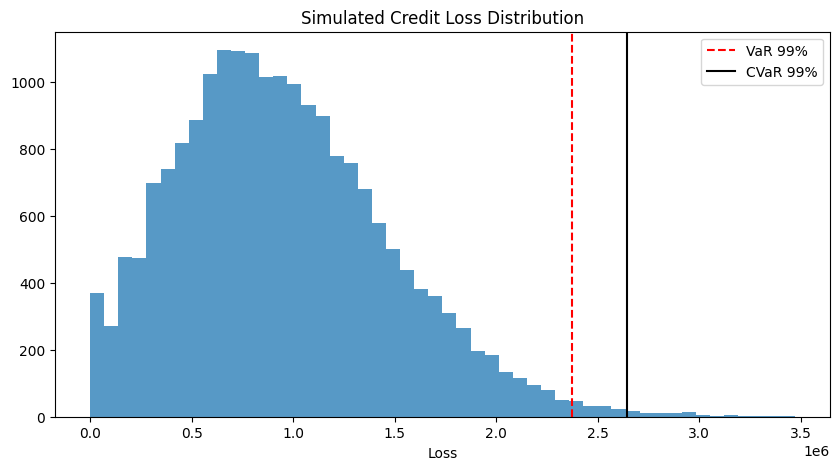

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(losses, bins=50, alpha=0.75)
ax.axvline(var_99, color="red", linestyle="--", label="VaR 99%")
ax.axvline(cvar_99, color="black", linestyle="-", label="CVaR 99%")
ax.set_title("Simulated Credit Loss Distribution")
ax.set_xlabel("Loss")
ax.legend();

## Rating Migration Simulation

In [10]:
ratings = ["AAA", "AA", "A", "BBB", "BB", "B", "D"]
transition_matrix = pd.DataFrame([
    [0.90, 0.08, 0.02, 0.00, 0.00, 0.00, 0.00],
    [0.02, 0.88, 0.08, 0.02, 0.00, 0.00, 0.00],
    [0.00, 0.03, 0.87, 0.08, 0.01, 0.00, 0.01],
    [0.00, 0.00, 0.04, 0.84, 0.08, 0.02, 0.02],
    [0.00, 0.00, 0.00, 0.05, 0.80, 0.10, 0.05],
    [0.00, 0.00, 0.00, 0.00, 0.08, 0.78, 0.14],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00],
], index=ratings, columns=ratings)

validate_transition_matrix(transition_matrix)
migration_paths = simulate_rating_migration(portfolio["rating"].head(10), transition_matrix, periods=5, random_state=42)
migration_paths

,obligor_0,obligor_1,obligor_2,obligor_3,obligor_4,obligor_5,obligor_6,obligor_7,obligor_8,obligor_9
period,,,,,,,,,,
rating,BB,BBB,BB,BBB,AA,B,BB,BB,AA,BBB
Unnamed 0,BB,BBB,B,BBB,AA,D,BB,BB,AA,BBB
Unnamed 1,BB,BB,B,BBB,AA,D,BB,BB,AA,BBB
Unnamed 2,BB,BB,D,BB,AA,D,BB,BBB,AA,BBB
Unnamed 3,BB,D,D,BB,AA,D,BB,BBB,AA,BBB
Unnamed 4,BB,D,D,BB,AA,D,BB,BBB,AA,BBB


## Merton Distance to Default

In [12]:
asset_value = 150
debt_face_value = 100
asset_vol = 0.25
risk_free_rate = 0.03
maturity = 1.0

pd.Series({
    "distance_to_default": merton_distance_to_default(asset_value, debt_face_value, asset_vol, risk_free_rate, maturity),
    "merton_pd": merton_pd(asset_value, debt_face_value, asset_vol, risk_free_rate, maturity),
})

distance_to_default    1.616860
merton_pd              0.052954
dtype: float64